# Explore here

Cargamos el Conjunto de Datos

In [1]:
import pandas as pd

total_data = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/NLP-project-tutorial/main/url_spam.csv")
total_data.head()

,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,True
1,https://www.hvper.com/,True
2,https://briefingday.com/m/v4n3i4f3,True
3,https://briefingday.com/n/20200618/m#commentform,False
4,https://briefingday.com/fan,True


Procesamos los Enlaces

In [2]:
print(total_data.shape)
total_data = total_data.drop_duplicates()
total_data = total_data.reset_index(inplace = False, drop = True)
total_data.shape

(2999, 2)


(2369, 2)

In [3]:
print(f"Spam: {len(total_data.loc[total_data.is_spam == 1])}")
print(f"No es spam: {len(total_data.loc[total_data.is_spam == 0])}")

Spam: 244
No es spam: 2125


In [5]:
#Procesamos el texto

import re  
import pandas as pd


def preprocess_text(text):
    # Conviertimos a minúsculas
    text = text.lower()
    
    # Eliminamos cualquier carácter que no sea letra o espacio
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # Eliminamos palabras de una sola letra
    text = re.sub(r'\b[a-z]\b', '', text)
    
    # Reemplazamos múltiples espacios por uno solo
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Eliminamos etiquetas HTML si las hubiera (no escapadas)
    text = re.sub(r'<.*?>', '', text)
    
    return text.split()

# Aplica la función al DataFrame
total_data["url"] = total_data["url"].apply(preprocess_text)
total_data.head()


,url,is_spam
0,"[https, briefingday, us, list, manage, com, un...",True
1,"[https, www, hvper, com]",True
2,"[https, briefingday, com]",True
3,"[https, briefingday, com, commentform]",False
4,"[https, briefingday, com, fan]",True


In [8]:
from nltk import download
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

download("wordnet")
download("stopwords")

# Inicializamos lematizador y lista de stopwords
lemmatizer = WordNetLemmatizer()
# Convertimos a set para más eficiencia
stop_words = set(stopwords.words("english")) 

# Función para lematizar y limpiar tokens
def lemmatize_text(words, lemmatizer=lemmatizer):
    # Lematizamos cada palabra
    tokens = [lemmatizer.lemmatize(word) for word in words]
    
    # Eliminamos stopwords
    tokens = [word for word in tokens if word not in stop_words]
    
    # Eliminamos palabras de 3 letras o menos
    tokens = [word for word in tokens if len(word) > 3]
    
    return tokens

# Aplicamos la función sobre la columna preprocesada
total_data["url"] = total_data["url"].apply(lemmatize_text)
total_data.head()

[nltk_data] Downloading package wordnet to /home/vscode/nltk_data...
[nltk_data] Downloading package stopwords to /home/vscode/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,url,is_spam
0,"[http, briefingday, list, manage, unsubscribe]",True
1,"[http, hvper]",True
2,"[http, briefingday]",True
3,"[http, briefingday, commentform]",False
4,"[http, briefingday]",True


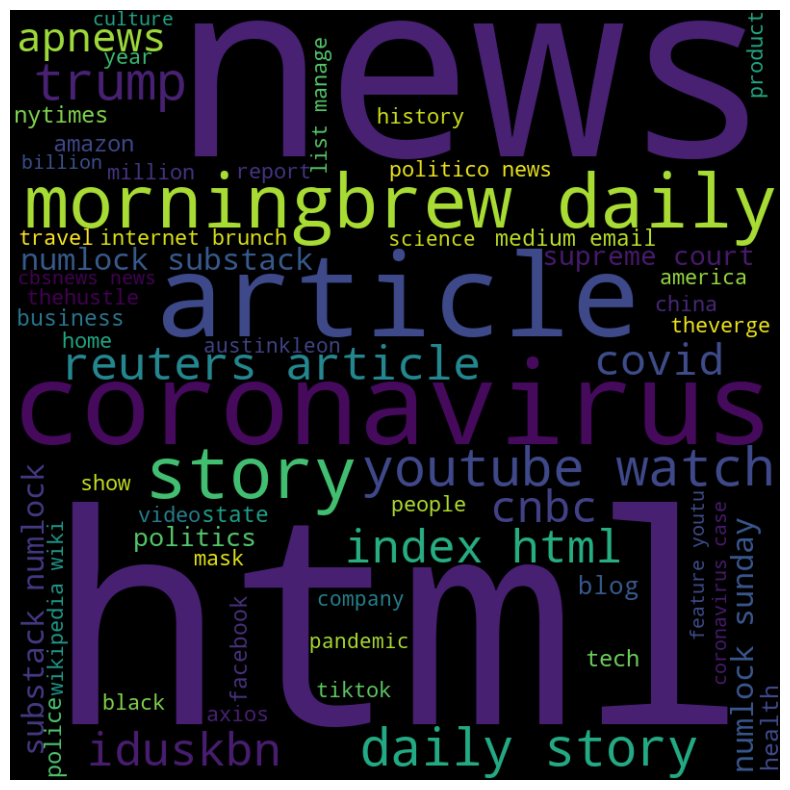

In [12]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Convertimos la columna de listas a un solo string
all_words = ' '.join([' '.join(words) for words in total_data["url"]])

# Creamos la nube de palabras
wordcloud = WordCloud(
    width=800,
    height=800,
    background_color="black",
    max_words=1000,
    min_font_size=20,
    random_state=42
).generate(all_words)

# Mostramos la nube de palabras
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.tight_layout()
plt.show()

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

tokens_list = total_data["url"]
tokens_list = [" ".join(tokens) for tokens in tokens_list]

vectorizer = TfidfVectorizer(max_features = 5000, max_df = 0.8, min_df = 5)
X = vectorizer.fit_transform(tokens_list).toarray()
y = total_data["is_spam"]

X[:5]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5, 546))

Dividimos en Train Test

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

Construimos SVM

In [15]:
from sklearn.svm import SVC

model = SVC(kernel = "linear", random_state = 42)
model.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

In [16]:
y_pred = model.predict(X_test)
y_pred

array([False, False,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True, False, False, False,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False,  True, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
        True, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [17]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.9514767932489452

Optimizamos el modelo

In [18]:
import numpy as np
from sklearn.model_selection import GridSearchCV

hyperparams = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    "kernel": ["linear", "poly", "rbf", "sigmoid", "precomputed’"],
    "degree": [1, 2, 3, 4, 5],
    "gamma": ["scale", "auto"]
}

# We initialize the random search
grid = GridSearchCV(model, hyperparams, scoring = "accuracy", cv = 5)
grid

GridSearchCV(cv=5, estimator=SVC(kernel='linear', random_state=42),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
                         'degree': [1, 2, 3, 4, 5], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'poly', 'rbf', 'sigmoid',
                                    'precomputed’']},
             scoring='accuracy')

In [19]:
grid.fit(X_train, y_train)

print(f"Best hyperparameters: {grid.best_params_}")

Best hyperparameters: {'C': 10, 'degree': 2, 'gamma': 'scale', 'kernel': 'poly'}


/home/vscode/.local/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
350 fits failed out of a total of 1750.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
350 fits failed with the following error:
Traceback (most recent call last):
  File "/home/vscode/.local/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/vscode/.local/lib/python3.11/site-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/home/vscode/.local/lib/python3.11/site-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/home/vscode/.l

In [20]:
opt_model = SVC(C = 1000, degree = 1, gamma = "auto", kernel = "poly", random_state = 42)
opt_model.fit(X_train, y_train)
y_pred = opt_model.predict(X_test)
accuracy_score(y_test, y_pred)

0.959915611814346

Guardamos el Modelo

In [21]:
from pickle import dump

dump(model, open("../models/SVM_Model.sav", "wb"))